# Dimensionality Reduction: Haar Wavelet Transform vs PCA

This project implements and compares two dimensionality reduction techniques — **Haar Wavelet Transform** and **Principal Component Analysis (PCA)** — applied to a high-dimensional dataset of 16,000 samples with 128 features each.

The goal is to reduce the number of features from 128 to 4 and evaluate how well each technique preserves the structure of the original data. Three metrics are used for comparison: computation time, distance relationship consistency, and normalized stress.

**Technologies:** Python, NumPy, Matplotlib

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import time

## 1. Data Loading

The dataset contains 16,000 samples with 128 features each, stored as a plain text file with space-separated values.

In [2]:
def load_data(file_path):
    """
    Load the dataset from a given file path.
    Args:
        file_path: str, path to the data file
    Returns:
        data: numpy array of shape (n_samples, n_features)
    """
    data = np.loadtxt(file_path)
    return data

data = load_data('../data/data.txt')
print('Data shape:', data.shape)

Data shape: (16000, 128)


## 2. Data Normalization

Row-wise z-score normalization is applied to each sample so that every row has mean 0 and standard deviation 1. This removes the effect of different scales across samples before computing distances or applying dimensionality reduction.

In [3]:
def normalize_data(X):
    """
    Normalize the data matrix X using row-wise z-score normalization.
    Args:
        X: numpy array of shape (n_samples, n_features)
    Returns:
        X_normalized: numpy array of shape (n_samples, n_features)
    """
    mean = np.mean(X, axis=1)
    std = np.std(X, axis=1)
    std[std == 0] = 1
    X_normalized = (X - mean[:, None]) / std[:, None]
    return X_normalized

data_norm = normalize_data(data)
print('Normalized data shape:', data_norm.shape)

Normalized data shape: (16000, 128)


## 3. Euclidean Distance Matrix

The pairwise Euclidean distance matrix captures the similarity between every pair of samples. This is used as the reference for evaluating how well each dimensionality reduction technique preserves the original data structure. The implementation uses vectorized NumPy broadcasting for efficiency.


In [4]:
def euclidean_distance_matrix(X):
    """
    Compute the pairwise Euclidean distance matrix for X.
    Args:
        X: numpy array of shape (n_samples, n_features)
    Returns:
        dist_matrix: numpy array of shape (n_samples, n_samples)
    """
    X_i = X[:, np.newaxis, :]
    X_j = X[np.newaxis, :, :]
    dist_matrix = np.sqrt(np.sum((X_i - X_j) ** 2, axis=2))
    return dist_matrix

dist_matrix = euclidean_distance_matrix(data_norm[:100])
print('Distance matrix shape:', dist_matrix.shape)


Distance matrix shape: (100, 100)


## 4. Haar Wavelet Transform

The Haar wavelet is the simplest wavelet transform. It works by recursively computing averages and differences of adjacent values, capturing both coarse and fine-grained structure in the data. The Haar matrix is generated and used to project each sample onto its first 4 basis vectors, reducing 128 features to 4.


In [5]:
def haar_matrix(n: int):
    """
    Generate an n x n Haar matrix.
    Args:
        n: int, size of the Haar matrix (must be a power of 2)
    Returns:
        H: numpy array of shape (n, n)
    """
    if n < 1 or (n & (n - 1)) != 0:
        raise ValueError('n must be a power of 2 and >= 1')
    H = np.array([[1.0]])
    while H.shape[0] < n:
        H = np.concatenate((
            np.kron(H, [1, 1]),
            np.kron(np.eye(H.shape[0]), [1, -1])
        ), axis=0)
    for i in range(n):
        non_zero_count = np.count_nonzero(H[i])
        if non_zero_count > 0:
            H[i] = H[i] / non_zero_count
    return H

H = haar_matrix(8)
print(H)

[[ 0.125  0.125  0.125  0.125  0.125  0.125  0.125  0.125]
 [ 0.125  0.125  0.125  0.125 -0.125 -0.125 -0.125 -0.125]
 [ 0.25   0.25  -0.25  -0.25   0.     0.    -0.    -0.   ]
 [ 0.     0.    -0.    -0.     0.25   0.25  -0.25  -0.25 ]
 [ 0.5   -0.5    0.    -0.     0.    -0.     0.    -0.   ]
 [ 0.    -0.     0.5   -0.5    0.    -0.     0.    -0.   ]
 [ 0.    -0.     0.    -0.     0.5   -0.5    0.    -0.   ]
 [ 0.    -0.     0.    -0.     0.    -0.     0.5   -0.5  ]]


In [6]:
def wavelet_transform(X, haar_n: int, reduced_n: int):
    """
    Apply Haar wavelet transform to X and reduce to reduced_n features.
    Args:
        X: numpy array of shape (n_samples, n_features)
        haar_n: int, size of the Haar matrix
        reduced_n: int, number of features to keep
    Returns:
        X_wavelet: numpy array of shape (n_samples, reduced_n)
    """
    H = haar_matrix(haar_n)
    X_wavelet_full = np.dot(X, H.T)
    X_wavelet = X_wavelet_full[:, :reduced_n]
    return X_wavelet

data_wavelet = wavelet_transform(data_norm, data_norm.shape[1], reduced_n=4)
print('Wavelet-transformed data shape:', data_wavelet.shape)

Wavelet-transformed data shape: (16000, 4)


## 5. Principal Component Analysis (PCA)

PCA finds the directions of maximum variance in the data by performing eigendecomposition of the covariance matrix. Projecting onto the top 4 eigenvectors reduces dimensionality while retaining as much variance as possible. The implementation is built from scratch using NumPy.


In [7]:
def pca(X, n_components: int):
    """
    Perform PCA on X and return the projected data with the top n_components.
    Args:
        X: numpy array of shape (n_samples, n_features)
        n_components: int, number of principal components to keep
    Returns:
        X_pca: numpy array of shape (n_samples, n_components)
    """
    X_centered = X - np.mean(X, axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    components = eigvecs[:, :n_components]
    X_pca = np.dot(X_centered, components)
    return X_pca

data_pca = pca(data_norm, 4)
print('PCA-transformed data shape:', data_pca.shape)

PCA-transformed data shape: (16000, 4)


## 6. Benchmarking and Comparison

This section compares Haar Wavelet Transform and PCA across three metrics:

1. **Elapsed Time** — how fast is computing Euclidean distances in the reduced space compared to the original
2. **Distance Relationship Consistency** — how often the relative ordering of distances between points is preserved
3. **Normalized Stress** — how well the actual magnitude of distances is preserved after reduction


### 6.1 Elapsed Time

Computing pairwise Euclidean distances in a lower-dimensional space is significantly faster. Here we measure the time for the full distance matrix computation on 1,000 samples across the original 128-feature space and the two 4-feature reduced spaces.


Time (original, 128 features): 1.2465s
Time (wavelet,    4 features): 0.0380s
Time (PCA,        4 features): 0.0425s

Speedup Wavelet vs Original: 32.8x
Speedup PCA     vs Original: 29.3x


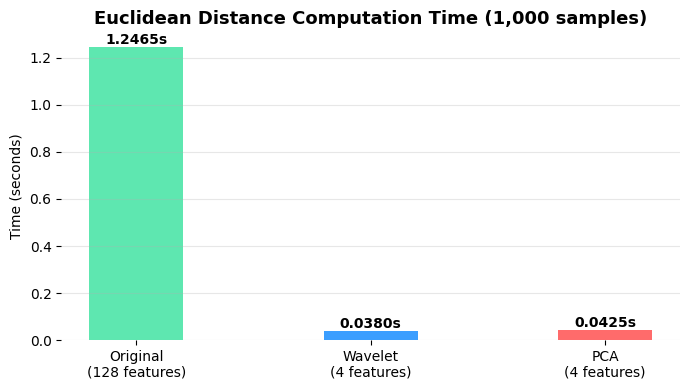

In [8]:
import os
os.makedirs('plots', exist_ok=True)
subset    = 1000
X_orig    = data_norm[:subset]
X_wavelet = wavelet_transform(X_orig, haar_n=X_orig.shape[1], reduced_n=4)
X_pca_red = pca(X_orig, n_components=4)

start = time.time()
dist_orig = euclidean_distance_matrix(X_orig)
time_orig = time.time() - start

start = time.time()
dist_wavelet = euclidean_distance_matrix(X_wavelet)
time_wavelet = time.time() - start

start = time.time()
dist_pca = euclidean_distance_matrix(X_pca_red)
time_pca = time.time() - start

print(f'Time (original, 128 features): {time_orig:.4f}s')
print(f'Time (wavelet,    4 features): {time_wavelet:.4f}s')
print(f'Time (PCA,        4 features): {time_pca:.4f}s')
print(f'\nSpeedup Wavelet vs Original: {time_orig/time_wavelet:.1f}x')
print(f'Speedup PCA     vs Original: {time_orig/time_pca:.1f}x')

fig, ax = plt.subplots(figsize=(7, 4))
methods = ['Original\n(128 features)', 'Wavelet\n(4 features)', 'PCA\n(4 features)']
times   = [time_orig, time_wavelet, time_pca]
colors  = ['#5ee7b0', '#3b9eff', '#ff6b6b']
bars = ax.bar(methods, times, color=colors, width=0.4, edgecolor='none')
ax.set_title('Euclidean Distance Computation Time (1,000 samples)', fontsize=13, fontweight='bold')
ax.set_ylabel('Time (seconds)')
for bar, v in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
            f'{v:.4f}s', ha='center', fontsize=10, fontweight='bold')
ax.spines[:].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Distance Relationship Consistency

For each randomly sampled triplet (A, B, C), we check whether the relative ordering — whether A is closer to B or to C — is preserved after dimensionality reduction. A score of 1.0 means perfect preservation and 0.5 would be random. Scores above 0.8 are generally considered good for downstream tasks like clustering or nearest-neighbor search.

Wavelet consistency: 0.8882 (88.82%)
PCA     consistency: 0.9367 (93.67%)


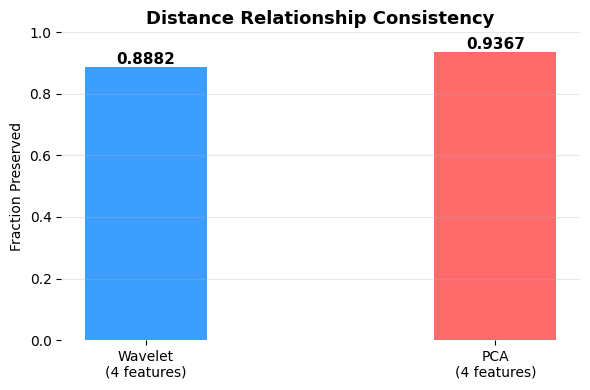

In [9]:
def relationship_consistency(dist_orig, dist_reduced, num_samples=10000, seed=42):
    """
    Check how often distance orderings (A-B > A-C) are preserved after reduction.
    Returns the fraction of sampled triplets where the ordering is consistent.
    """
    np.random.seed(seed)
    n = dist_orig.shape[0]
    preserved = 0
    for _ in range(num_samples):
        a, b, c = np.random.choice(n, 3, replace=False)
        if (dist_orig[a, b] > dist_orig[a, c]) == (dist_reduced[a, b] > dist_reduced[a, c]):
            preserved += 1
    return preserved / num_samples

cons_wavelet = relationship_consistency(dist_orig, dist_wavelet)
cons_pca     = relationship_consistency(dist_orig, dist_pca)

print(f'Wavelet consistency: {cons_wavelet:.4f} ({cons_wavelet*100:.2f}%)')
print(f'PCA     consistency: {cons_pca:.4f} ({cons_pca*100:.2f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
methods = ['Wavelet\n(4 features)', 'PCA\n(4 features)']
values  = [cons_wavelet, cons_pca]
colors  = ['#3b9eff', '#ff6b6b']
bars = ax.bar(methods, values, color=colors, width=0.35, edgecolor='none')
ax.set_title('Distance Relationship Consistency', fontsize=13, fontweight='bold')
ax.set_ylabel('Fraction Preserved')
ax.set_ylim([0, 1])
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.spines[:].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/consistency.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Normalized Stress

Normalized stress (Kruskal's stress formula) measures how much the actual distance values change after reduction. Unlike consistency which only checks ordering, stress penalizes large differences in distance magnitudes. A value of 0 means perfect preservation and 1 means the distances are completely different.

Wavelet stress: 0.9143
PCA     stress: 0.1721

PCA preserves distances better (lower stress: 0.1721 vs 0.9143)


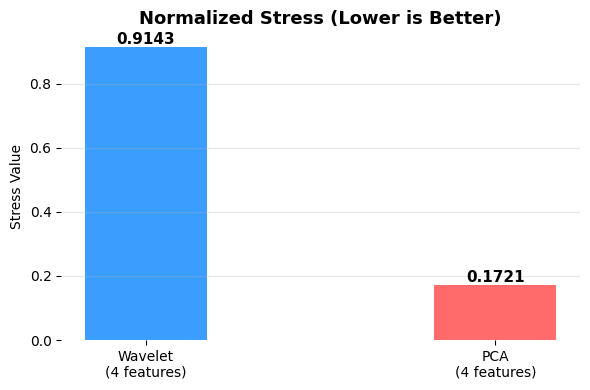

In [10]:
def normalized_stress(dist_orig, dist_reduced):
    """
    Kruskal's stress formula — measures how well distances are preserved.
    Lower is better. 0 = perfect preservation.
    """
    n = dist_orig.shape[0]
    mask = np.triu(np.ones((n, n)), k=1).astype(bool)
    orig_d    = dist_orig[mask]
    reduced_d = dist_reduced[mask]
    stress = np.sqrt(np.sum((orig_d - reduced_d)**2) / np.sum(orig_d**2))
    return stress

stress_wavelet = normalized_stress(dist_orig, dist_wavelet)
stress_pca     = normalized_stress(dist_orig, dist_pca)

print(f'Wavelet stress: {stress_wavelet:.4f}')
print(f'PCA     stress: {stress_pca:.4f}')

if stress_pca < stress_wavelet:
    print(f'\nPCA preserves distances better (lower stress: {stress_pca:.4f} vs {stress_wavelet:.4f})')
else:
    print(f'\nWavelet preserves distances better (lower stress: {stress_wavelet:.4f} vs {stress_pca:.4f})')

fig, ax = plt.subplots(figsize=(6, 4))
methods = ['Wavelet\n(4 features)', 'PCA\n(4 features)']
values  = [stress_wavelet, stress_pca]
colors  = ['#3b9eff', '#ff6b6b']
bars = ax.bar(methods, values, color=colors, width=0.35, edgecolor='none')
ax.set_title('Normalized Stress (Lower is Better)', fontsize=13, fontweight='bold')
ax.set_ylabel('Stress Value')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
            f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.spines[:].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/normalized_stress.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Verification
The cells below verify each function against known expected outputs to confirm correctness.

In [11]:
import numpy as np

eval_data = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1.1, 0.9, 1, 1, 1, 1, 1, 1],
    [0.95, 1.05, 1, 1, 1, 1, 1, 1],
    [1, 1, 1.1, 0.9, 1, 1, 1, 1],
    [-1, -1, -1, -1, -1, -1, -1, -1],
    [-1.1, -0.9, -1, -1, -1, -1, -1, -1],
    [-0.95, -1.05, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1.1, -0.9, -1, -1, -1, -1]
])

def all_close(actual, expected, tol=1e-4, no_sign=False):

    if isinstance(expected, list):
        correct_1 = any([np.allclose(actual, e, atol=tol) for e in expected])
        correct_2 = any([np.allclose(np.abs(actual), np.abs(e), atol=tol) for e in expected]) if no_sign else False
        correct = correct_1 or correct_2
    else:
        correct = np.allclose(actual, expected, atol=tol) if not no_sign else np.allclose(np.abs(actual), np.abs(expected), atol=tol)

    if not correct:
        print("The function is NOT working correctly.")
        print("Expected result:")
        print(expected)
        print("Actual result:")
        print(actual)
    else:
        print("The function is working correctly.")
        print("Actual result:")
        print(actual)

In [12]:
# DISTANCE MATRIX
expected_result = np.array(
    [
        [0.    , 0.1414, 0.0707, 0.1414, 5.6569, 5.6586, 5.6573, 5.6586],
        [0.1414, 0.    , 0.2121, 0.2   , 5.6586, 5.6639, 5.6573, 5.6604],
        [0.0707, 0.2121, 0.    , 0.1581, 5.6573, 5.6573, 5.6586, 5.6591],
        [0.1414, 0.2   , 0.1581, 0.    , 5.6586, 5.6604, 5.6591, 5.6639],
        [5.6569, 5.6586, 5.6573, 5.6586, 0.    , 0.1414, 0.0707, 0.1414],
        [5.6586, 5.6639, 5.6573, 5.6604, 0.1414, 0.    , 0.2121, 0.2   ],
        [5.6573, 5.6573, 5.6586, 5.6591, 0.0707, 0.2121, 0.    , 0.1581],
        [5.6586, 5.6604, 5.6591, 5.6639, 0.1414, 0.2   , 0.1581, 0.    ]
    ]
)

actual_result = euclidean_distance_matrix(eval_data)
# compare the distance matrix with the expected result
all_close(actual_result, expected_result)

The function is working correctly.
Actual result:
[[0.         0.14142136 0.07071068 0.14142136 5.65685425 5.65862174
  5.65729617 5.65862174]
 [0.14142136 0.         0.21213203 0.2        5.65862174 5.6639209
  5.65729617 5.66038868]
 [0.07071068 0.21213203 0.         0.15811388 5.65729617 5.65729617
  5.65862174 5.65906353]
 [0.14142136 0.2        0.15811388 0.         5.65862174 5.66038868
  5.65906353 5.6639209 ]
 [5.65685425 5.65862174 5.65729617 5.65862174 0.         0.14142136
  0.07071068 0.14142136]
 [5.65862174 5.6639209  5.65729617 5.66038868 0.14142136 0.
  0.21213203 0.2       ]
 [5.65729617 5.65729617 5.65862174 5.65906353 0.07071068 0.21213203
  0.         0.15811388]
 [5.65862174 5.66038868 5.65906353 5.6639209  0.14142136 0.2
  0.15811388 0.        ]]


In [13]:
# wavelet transform with example in class
S = np.array([
    [2, 2, 0, 2, 3, 5, 4, 4],
])

expected_result = np.array([2.75, -1.25,  0.5,   0.,    0.,   -1.,   -1.,    0. ])
actual_result = wavelet_transform(S, haar_n=S.shape[1], reduced_n=8)
all_close(actual_result, expected_result)

The function is working correctly.
Actual result:
[[ 2.75 -1.25  0.5   0.    0.   -1.   -1.    0.  ]]


In [14]:
# wavelet
expected_result = np.array([
    [ 0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.],
    [ 0.,  0., -0.,  0.],
    [ 0.,  0.,  0.,  0.],
    [-0., -0., -0.,  0.],
    [ 0.,  0.,  0.,  0.],
    [-0., -0.,  0.,  0.]]
    )

data = normalize_data(eval_data)
actual_result = wavelet_transform(data, haar_n=data.shape[1], reduced_n=4)
# compare the wavelet transformed data with the expected result
all_close(actual_result, expected_result)


The function is working correctly.
Actual result:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.49800181e-16  2.49800181e-16  4.99600361e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.49800181e-16  2.49800181e-16 -4.99600361e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.49800181e-16 -2.49800181e-16 -4.99600361e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.49800181e-16 -2.49800181e-16  4.99600361e-16  0.00000000e+00]]


In [15]:
# PCA
expected_result_center = np.array([
    [ 0.    ,  0.    ,  0.    ,  0.    ],
    [ 2.8284,  0.    ,  0.    ,  0.    ],
    [-2.8284,  0.    ,  0.    ,  0.    ],
    [ 0.    ,  2.8284,  0.    ,  0.    ],
    [ 0.    ,  0.    ,  0.    ,  0.    ],
    [-2.8284,  0.    , -0.    ,  0.    ],
    [ 2.8284,  0.    , -0.    ,  0.    ],
    [ 0.    , -2.8284,  0.    , -0.    ]])

expected_result_2_znorm = np.array([
    [ 0.    ,  0.    ,  0.    ,  0.    ],
    [ 2.    ,  0.    ,  0.    ,  0.    ],
    [-2.    ,  0.    ,  0.    ,  0.    ],
    [ 0.    ,  2.8284,  0.    ,  0.    ],
    [ 0.    ,  0.    ,  0.    ,  0.    ],
    [-2.    ,  0.    , -0.    ,  0.    ],
    [ 2.    ,  0.    , -0.    ,  0.    ],
    [ 0.    , -2.8284,  0.    , -0.    ]])

data = normalize_data(eval_data)
actual_result = pca(data, n_components=4)
# compare the PCA transformed data with the expected result
all_close(actual_result, [expected_result_center, expected_result_2_znorm], no_sign=True)

The function is working correctly.
Actual result:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.82842712e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.82842712e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -2.82842712e+00 -1.18912415e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.82842712e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.82842712e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.82842712e+00  1.18912415e-16  0.00000000e+00]]
